In [1]:
import pandas as pd
import numpy as np
import datetime
import xlrd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = 'Superstore_Data.xlsx'
orders_df = pd.read_excel(file_path, sheet_name='Orders')

In [3]:
print("\n--- Original Data Information ---")
print(orders_df.info())


--- Original Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object

In [4]:
# Datetime check
def ensure_datetime(col):
    if pd.api.types.is_datetime64_any_dtype(col):
        return col
    return pd.to_datetime(col, unit='D', origin=pd.Timestamp('1899-12-30'), errors='coerce')

# Apply datetime check
if 'Order Date' in orders_df.columns:
    orders_df['Order Date'] = ensure_datetime(orders_df['Order Date'])
if 'Ship Date' in orders_df.columns:
    orders_df['Ship Date'] = ensure_datetime(orders_df['Ship Date'])

# Feature Engineering
# Extract the year and month, create Year-Month
orders_df['Order Year'] = orders_df['Order Date'].dt.year
orders_df['Order Month'] = orders_df['Order Date'].dt.month
orders_df['Order Year-Month'] = orders_df['Order Date'].dt.to_period('M')

# Calculate Profit Margin
orders_df['Profit Margin'] = orders_df.apply(lambda row: row['Profit'] / row['Sales'] if row['Sales'] != 0 else 0, axis=1)

# Data Deduplication
original_rows = len(orders_df)
orders_df.drop_duplicates(inplace=True)
deduped_rows = len(orders_df)

print(f"\n--- Data Preprocessing Report ---")
print(f"Original Rows: {original_rows}")
print(f"Deduped Rows: {deduped_rows} ({original_rows - deduped_rows} rows delete)")
print(f"Date from {orders_df['Order Date'].min()} to {orders_df['Order Date'].max()}")
print("\n--- 5 Rows after Preprocessing ---")
print(orders_df[['Order ID', 'Order Date', 'Customer Name', 'Sales', 'Profit', 'Order Year', 'Profit Margin']].head())


--- Data Preprocessing Report ---
Original Rows: 9994
Deduped Rows: 9994 (0 rows delete)
Date from 2015-01-03 00:00:00 to 2018-12-30 00:00:00

--- 5 Rows after Preprocessing ---
         Order ID Order Date    Customer Name     Sales    Profit  Order Year  \
0  CA-2017-152156 2017-11-08      Claire Gute  261.9600   41.9136        2017   
1  CA-2017-152156 2017-11-08      Claire Gute  731.9400  219.5820        2017   
2  CA-2017-138688 2017-06-12  Darrin Van Huff   14.6200    6.8714        2017   
3  US-2016-108966 2016-10-11   Sean O'Donnell  957.5775 -383.0310        2016   
4  US-2016-108966 2016-10-11   Sean O'Donnell   22.3680    2.5164        2016   

   Profit Margin  
0         0.1600  
1         0.3000  
2         0.4700  
3        -0.4000  
4         0.1125  


In [5]:
# Clustering Part -- Feature Engineering

# Set the base date as the last day of the data set plus one day.
current_date = orders_df['Order Date'].max() + datetime.timedelta(days=1)

# Group data by customer ID
customer_df = orders_df.groupby('Customer ID').agg({
    'Order Date': lambda x: (current_date - x.max()).days,  # R: Recency
    'Order ID': 'nunique',                                  # F: Frequency
    'Sales': 'sum',                                         # M: Monetary
    'Profit': 'sum'                                         # P: Profit
}).reset_index()

# Rename column
customer_df.rename(columns={
    'Order Date': 'Recency',
    'Order ID': 'Frequency',
    'Sales': 'Monetary',
    'Profit': 'Total_Profit'
}, inplace=True)

print("--- RFM ---")
print(customer_df.head())

--- RFM ---
  Customer ID  Recency  Frequency  Monetary  Total_Profit
0    AA-10315      185          5  5563.560     -362.8825
1    AA-10375       20          9  1056.390      277.3824
2    AA-10480      260          4  1790.512      435.8274
3    AA-10645       56          6  5086.935      857.8033
4    AB-10015      416          3   886.156      129.3465


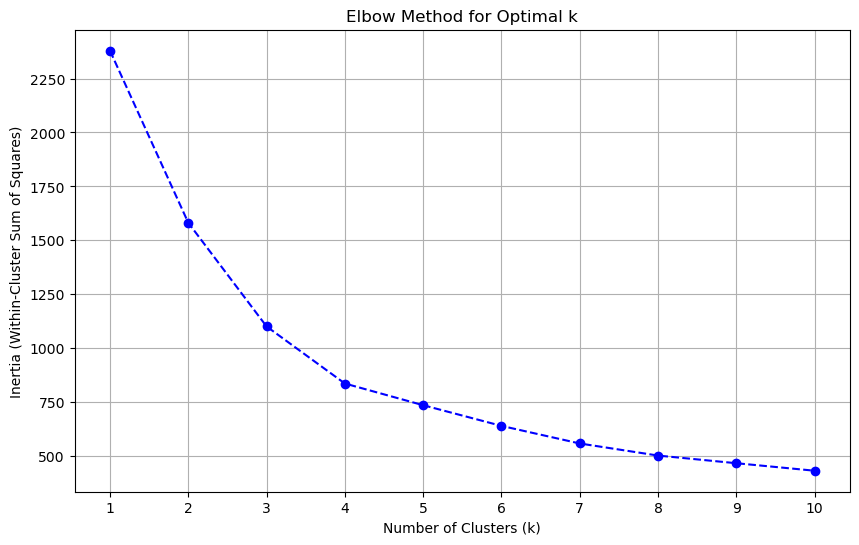

In [6]:
# Normalization
scaler = StandardScaler()

features = ['Recency', 'Frequency', 'Monetary']
X_scaled = scaler.fit_transform(customer_df[features])

# Elbow plot
inertia = []
K_range = range(1, 11)

for k in K_range:
    # Training K-Means models with different k values
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia.append(kmeans_temp.inertia_)

# Drawing an elbow plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [7]:
# Use K-means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)


--- Summary of Clustering Results (Mean) ---
            Recency  Frequency     Monetary  Total_Profit
Cluster                                                  
0         72.286667   8.506667  3308.286885    349.677786
1        101.777778   4.717718  1672.318202    182.709240
2        123.718750   8.296875  9479.545687   1676.157072
3        559.250000   3.697917  1470.228226    139.348503

--- Number of customers in each cluster ---
Cluster
1    333
0    300
3     96
2     64
Name: count, dtype: int64


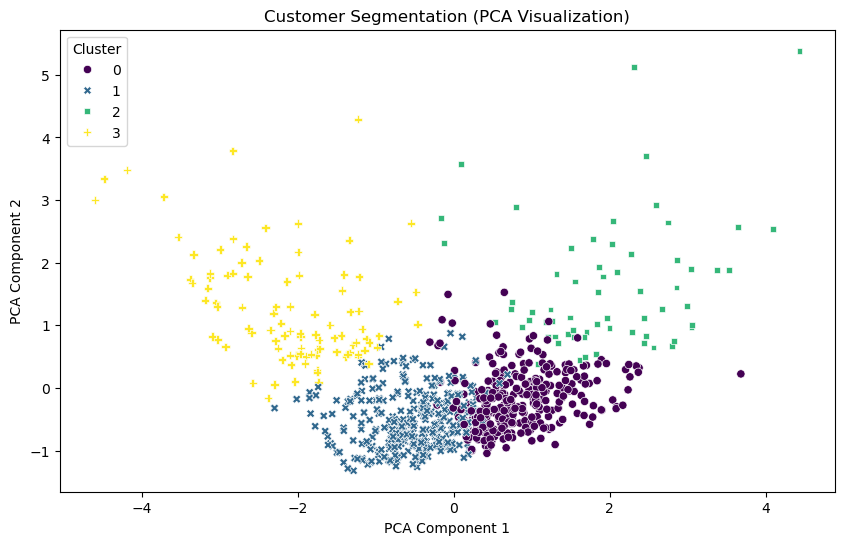

In [8]:
# Result Analysis
# Calculate the mean feature value for each cluster
cluster_summary = customer_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'Total_Profit']].mean()
cluster_counts = customer_df['Cluster'].value_counts()

print("\n--- Summary of Clustering Results (Mean) ---")
print(cluster_summary)
print("\n--- Number of customers in each cluster ---")
print(cluster_counts)

# Using PCA to reduce the dimensionality of multidimensional data to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
customer_df['PCA1'] = X_pca[:, 0]
customer_df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', style='Cluster')
plt.title('Customer Segmentation (PCA Visualization)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


--- LDA Classification Report (Predicting Segments) ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        84
           1       0.95      0.98      0.97       104
           2       0.95      0.95      0.95        22
           3       1.00      0.89      0.94        28

    accuracy                           0.96       238
   macro avg       0.97      0.95      0.95       238
weighted avg       0.96      0.96      0.96       238


--- Confusion Matrix ---
[[ 80   3   1   0]
 [  2 102   0   0]
 [  1   0  21   0]
 [  1   2   0  25]]

--- LDA Coefficients ---
          Recency  Frequency  Monetary  Total_Profit  Discount
Class 0 -0.005966   0.877464  0.000187     -0.000023  0.101078
Class 1 -0.005279  -0.691023 -0.000512     -0.000103  0.527498
Class 2 -0.000165   0.725633  0.002762      0.001223 -4.371519
Class 3  0.036831  -0.908301 -0.000573     -0.000336  0.602556


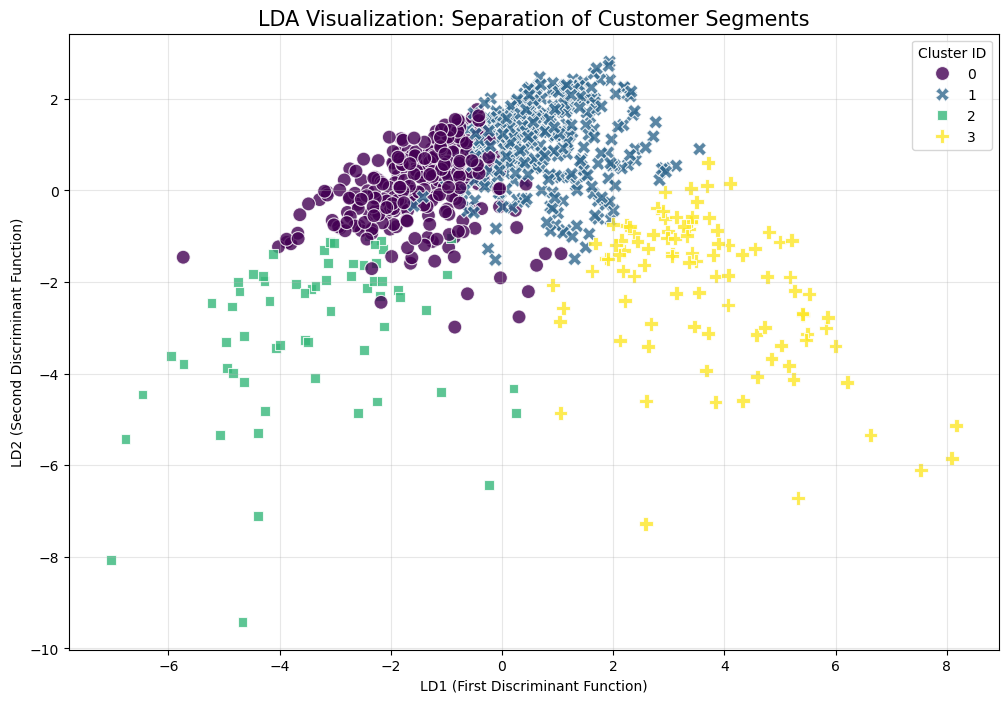

In [9]:
# Discriminant analysis: Return Prediction
# Objective: Distinguish clusters using R, F, M, Profit, and Discount
feature_cols = ['Recency', 'Frequency', 'Monetary', 'Total_Profit']
X = customer_df[feature_cols].copy() 
X['Discount'] = orders_df['Discount']
y = customer_df['Cluster']

# Update
feature_cols = ['Recency', 'Frequency', 'Monetary', 'Total_Profit', 'Discount']

# Split training/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predict
y_pred = lda.predict(X_test)

# 3. Results and Visualisation
print("\n--- LDA Classification Report (Predicting Segments) ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# View the coefficient matrix
coef_df = pd.DataFrame(lda.coef_, columns=feature_cols, index=[f'Class {i}' for i in lda.classes_])
print("\n--- LDA Coefficients ---")
print(coef_df)

# Visualising LDA Projections (The Most Crucial Part)
# LDA projects data onto two dimensions, LD1 and LD2, maximising category differentiation.
X_lda = lda.transform(X)
customer_df['LD1'] = X_lda[:, 0]
customer_df['LD2'] = X_lda[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=customer_df, 
    x='LD1', 
    y='LD2', 
    hue='Cluster', 
    palette='viridis', 
    style='Cluster',
    s=100, 
    alpha=0.8
)
plt.title('LDA Visualization: Separation of Customer Segments', fontsize=15)
plt.xlabel('LD1 (First Discriminant Function)')
plt.ylabel('LD2 (Second Discriminant Function)')
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()